In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# prepare the dataset
df=pd.read_csv('student-scores.csv')
print(df.head())
print(f"\nRows and Columns: {df.shape}")
df = df.drop(columns=['id', 'first_name', 'last_name', 'email', 'career_aspiration'])
print(f"\nMissing valus: \n{df.isnull().sum()} and \nTotal missing:{df.isnull().sum().sum()}")
df=df.dropna()


categorical_cols=df.select_dtypes(exclude=['int64','float64']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

for col in categorical_cols:
    df[col]=df[col].astype('category').cat.codes

print(f"\nDATA TYPES AFTER ENCODING: \n{df.dtypes}")

print(f"\nDATASET AFTER PREPARATION: \n{df.head()}")


   id first_name last_name                                  email  gender  \
0   1       Paul     Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle  Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina   Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara     Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony    Campos     anthony.campos.5@gslingacademy.com    male   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False             2                       False   
2          False             9                        True   
3          False             5                       False   
4          False             5                       False   

   weekly_self_study_hours   career_aspiration  math_score  history_score  \
0                       27              Lawyer          73             81   
1         

Full correlation Matrix: 
                            gender  part_time_job  absence_days  \
gender                        1.00          -0.02         -0.03   
part_time_job                -0.02           1.00          0.21   
absence_days                 -0.03           0.21          1.00   
extracurricular_activities   -0.01          -0.01          0.03   
weekly_self_study_hours       0.08          -0.21         -0.29   
math_score                    0.05          -0.19         -0.24   
history_score                -0.01          -0.11         -0.13   
physics_score                 0.05          -0.12         -0.14   
chemistry_score              -0.03          -0.09         -0.08   
biology_score                 0.03          -0.00         -0.09   
english_score                -0.04          -0.10         -0.08   
geography_score              -0.01          -0.03         -0.00   

                            extracurricular_activities  \
gender                                      

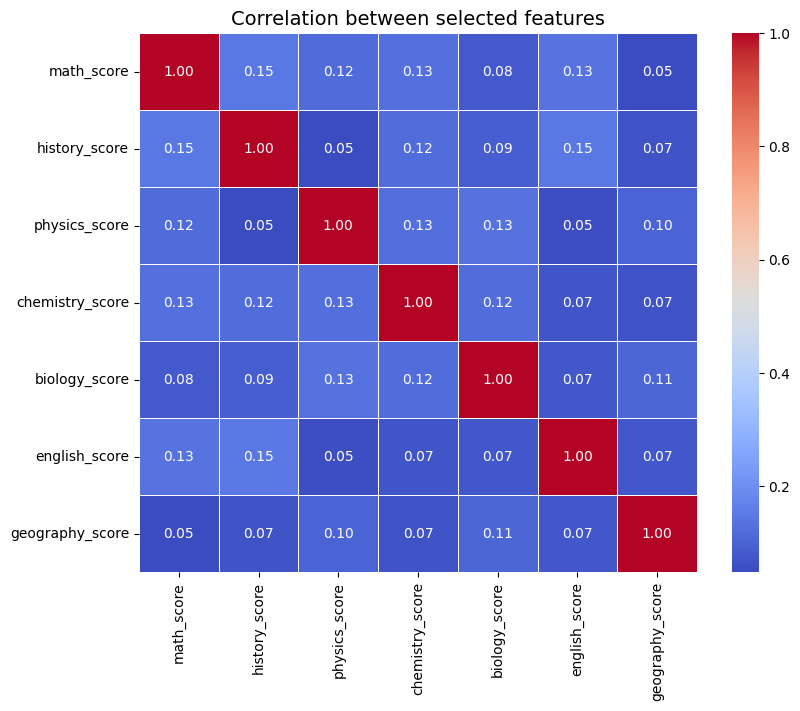

In [31]:
#feature selection
print(f"Full correlation Matrix: \n{df.corr().round(2)}")
features = ['math_score', 'history_score', 'physics_score', 'chemistry_score','biology_score', 'english_score', 'geography_score'] #directly measure student perfomance
X=df[features]
print(X.head())
print(f"\nNumber of features: {len(features)}")
print(f"\nNumber of students: {X.shape[0]}")
print(f"\nFEATURE Statistics: \n{X.describe().round(2)}")

plt.figure(figsize=(9,7))
sns.heatmap(X.corr(),annot=True,fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title('Correlation between selected features',fontsize=14)
plt.tight_layout
plt.show()


Using all score features gives the most complete picture of a student.
A student might be strong in STEM but weak in language — this nuance
is only captured when all subjects are included.
All features are on the same scale (0-100), so no normalization needed.
Including more relevant features leads to more meaningful clusters.

In [32]:
# K-Means Clustering Algorithm

class KMeansManual:
    def __init__(self,k=3,max_iters=300,random_state=42):
        self.k=k
        self.max_iters=max_iters
        self.random_state=random_state
        self.centroids=None
        self.labels=None
        self.inertia=None # метрика качества
        self.n_iters=0 

    def fit(self,X):
        np.random.seed(self.random_state)
        X=np.array(X,dtype=float) 

        #pick 1st centroid randomly
        idx=np.random.randint(0,X.shape[0]) #initialize centroids using kmeans++ strategy
        self.centroids=[X[idx]]

        for _ in range(self.k-1):
            distances=np.array([min(np.sum((x-c)**2) for c in self.centroids) for x in X])
            
            probs=distances/distances.sum()
            cumulative=np.cumsum(probs)
            r=np.random.rand()
            for j,p in enumerate(cumulative):
                if r <= p:
                    self.centroids.append(X[j])
                    break

        self.centroids=np.array(self.centroids)

        for iteration in range(self.max_iters):
            # Assign clusters
            labels = self._assign_clusters(X)

            # Update centroids
            new_centroids = np.array([
                X[labels == i].mean(axis=0)
                if np.sum(labels == i) > 0
                else self.centroids[i]
                for i in range(self.k)
            ])

            # Check convergence
            if np.allclose(self.centroids, new_centroids, atol=1e-6):
                self.n_iters = iteration + 1
                break

            self.centroids = new_centroids
            self.n_iters = iteration + 1

        self.labels = self._assign_clusters(X)

        # Calculate inertia
        self.inertia = sum(
            np.sum((X[self.labels == i] - self.centroids[i]) ** 2)
            for i in range(self.k)
        )
        return self

    def _assign_clusters(self, X):
        distances = np.array([
            np.sqrt(np.sum((X - c) ** 2, axis=1))
            for c in self.centroids
        ])
        return np.argmin(distances, axis=0)

    def predict(self, X):
        return self._assign_clusters(np.array(X, dtype=float))
print("K-Means Clustering defined successfully.")

K-Means Clustering defined successfully.


COMPARING MULTIPLE K VALUES

   K |         Inertia |  Converged at iter
K= 2 |    1,926,595.49 | iter 24
K= 3 |    1,729,913.09 | iter 28
K= 4 |    1,601,337.61 | iter 35
K= 5 |    1,505,486.87 | iter 48
K= 6 |    1,424,474.03 | iter 39
K= 7 |    1,358,399.81 | iter 40
K= 8 |    1,321,749.75 | iter 26
K= 9 |    1,271,996.37 | iter 45
K=10 |    1,238,345.89 | iter 37

 INERTIA DROP BETWEEN K VALUES
K=2 → K=3: drop = 196,682.40 (10.2%)
K=3 → K=4: drop = 128,575.48 (7.4%)
K=4 → K=5: drop = 95,850.74 (6.0%)
K=5 → K=6: drop = 81,012.84 (5.4%)
K=6 → K=7: drop = 66,074.22 (4.6%)
K=7 → K=8: drop = 36,650.06 (2.7%)
K=8 → K=9: drop = 49,753.38 (3.8%)
K=9 → K=10: drop = 33,650.48 (2.6%)


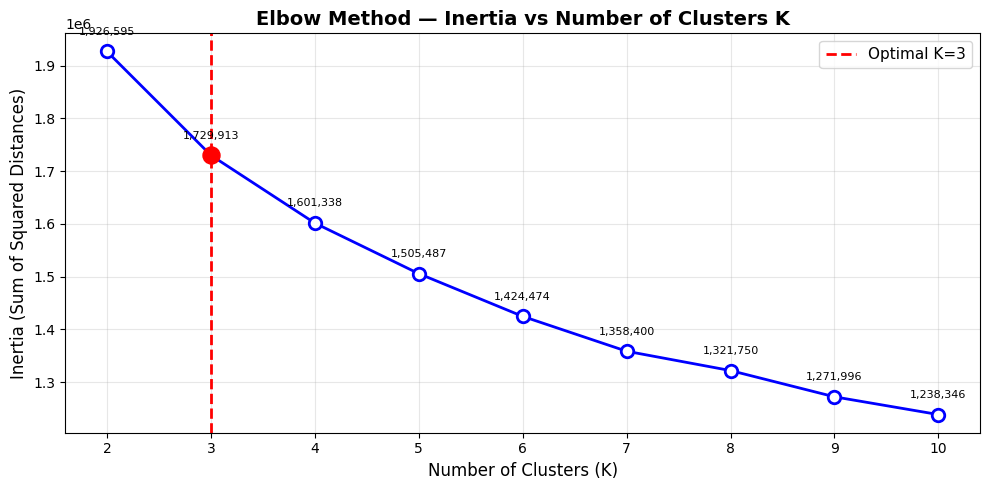

In [33]:
#determine number of clusters

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertias = []
models = {}
iterations_used = []

print("COMPARING MULTIPLE K VALUES\n")
print(f"{'K':>4} | {'Inertia':>15} | {'Converged at iter':>18}")

for k in k_values:
    model = KMeansManual(k=k, max_iters=300, random_state=42)
    model.fit(X.values)
    inertias.append(model.inertia)
    models[k] = model
    iterations_used.append(model.n_iters)
    print(f"K={k:>2} | {model.inertia:>15,.2f} | iter {model.n_iters}")

# Calculate inertia drop between consecutive K values
print("\n INERTIA DROP BETWEEN K VALUES")
for i in range(1, len(k_values)):
    drop = inertias[i-1] - inertias[i]
    pct = drop / inertias[i-1] * 100
    print(f"K={k_values[i-1]} → K={k_values[i]}: drop = {drop:,.2f} ({pct:.1f}%)")

# Elbow plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, inertias, 'bo-', linewidth=2,
         markersize=9, markerfacecolor='white', markeredgewidth=2)

optimal_k = 3
plt.axvline(x=optimal_k, color='red', linestyle='--',
            linewidth=2, label=f'Optimal K={optimal_k}')
plt.scatter([optimal_k], [inertias[k_values.index(optimal_k)]],
            color='red', s=150, zorder=5)

for k, inertia in zip(k_values, inertias):
    plt.annotate(f'{inertia:,.0f}',
                 (k, inertia),
                 textcoords="offset points",
                 xytext=(0, 12),
                 ha='center', fontsize=8)

plt.title('Elbow Method — Inertia vs Number of Clusters K',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Clustering Results 
# Part C. Comparison of multiple K values

print("DETAILED RESULTS FOR MULTIPLE K VALUES\n")

for k in [2, 3, 4, 5, 6]:
    model = models[k]
    labels = model.labels
    unique, counts = np.unique(labels, return_counts=True)

    print(f"K = {k}")
    print(f"Inertia: {model.inertia:,.2f}")
    print(f"Cluster distribution:")
    for cluster, count in zip(unique, counts):
        pct = count / len(labels) * 100
        bar = '█' * int(pct / 2)
        print(f"  Cluster {cluster}: {count:>4} students "
              f"({pct:>5.1f}%) {bar}")
    print()

# Final model with optimal K=3
optimal_k = 3
final_model = models[optimal_k]
final_labels = final_model.labels

# Add cluster labels to dataset
df['cluster'] = final_labels

print("FINAL CLUSTERING WITH OPTIMAL K=3")
print(f"\nTotal students clustered: {len(final_labels)}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

print("\nCLUSTER PROFILES — MEAN SCORES")
cluster_profiles = df.groupby('cluster')[features].mean().round(2)
print(cluster_profiles)

print("\nCLUSTER PROFILES — DETAILED")
for i in range(optimal_k):
    group = df[df['cluster'] == i]
    avg = cluster_profiles.loc[i].mean()
    strongest = cluster_profiles.loc[i].idxmax()
    weakest = cluster_profiles.loc[i].idxmin()
    print(f"\nCluster {i} ({len(group)} students):")
    print(f"  Overall average score: {avg:.2f}")
    print(f"  Strongest subject:     {strongest} "
          f"({cluster_profiles.loc[i][strongest]:.2f})")
    print(f"  Weakest subject:       {weakest} "
          f"({cluster_profiles.loc[i][weakest]:.2f})")

print("\nCENTROIDS (K=3)")
centroids_df = pd.DataFrame(
    final_model.centroids,
    columns=features
).round(2)
centroids_df.index.name = 'Cluster'
print(centroids_df)


DETAILED RESULTS FOR MULTIPLE K VALUES

K = 2
Inertia: 1,926,595.49
Cluster distribution:
  Cluster 0: 1012 students ( 50.6%) █████████████████████████
  Cluster 1:  988 students ( 49.4%) ████████████████████████

K = 3
Inertia: 1,729,913.09
Cluster distribution:
  Cluster 0:  424 students ( 21.2%) ██████████
  Cluster 1:  747 students ( 37.4%) ██████████████████
  Cluster 2:  829 students ( 41.4%) ████████████████████

K = 4
Inertia: 1,601,337.61
Cluster distribution:
  Cluster 0:  332 students ( 16.6%) ████████
  Cluster 1:  500 students ( 25.0%) ████████████
  Cluster 2:  581 students ( 29.0%) ██████████████
  Cluster 3:  587 students ( 29.3%) ██████████████

K = 5
Inertia: 1,505,486.87
Cluster distribution:
  Cluster 0:  432 students ( 21.6%) ██████████
  Cluster 1:  400 students ( 20.0%) ██████████
  Cluster 2:  477 students ( 23.8%) ███████████
  Cluster 3:  392 students ( 19.6%) █████████
  Cluster 4:  299 students ( 14.9%) ███████

K = 6
Inertia: 1,424,474.03
Cluster distributi

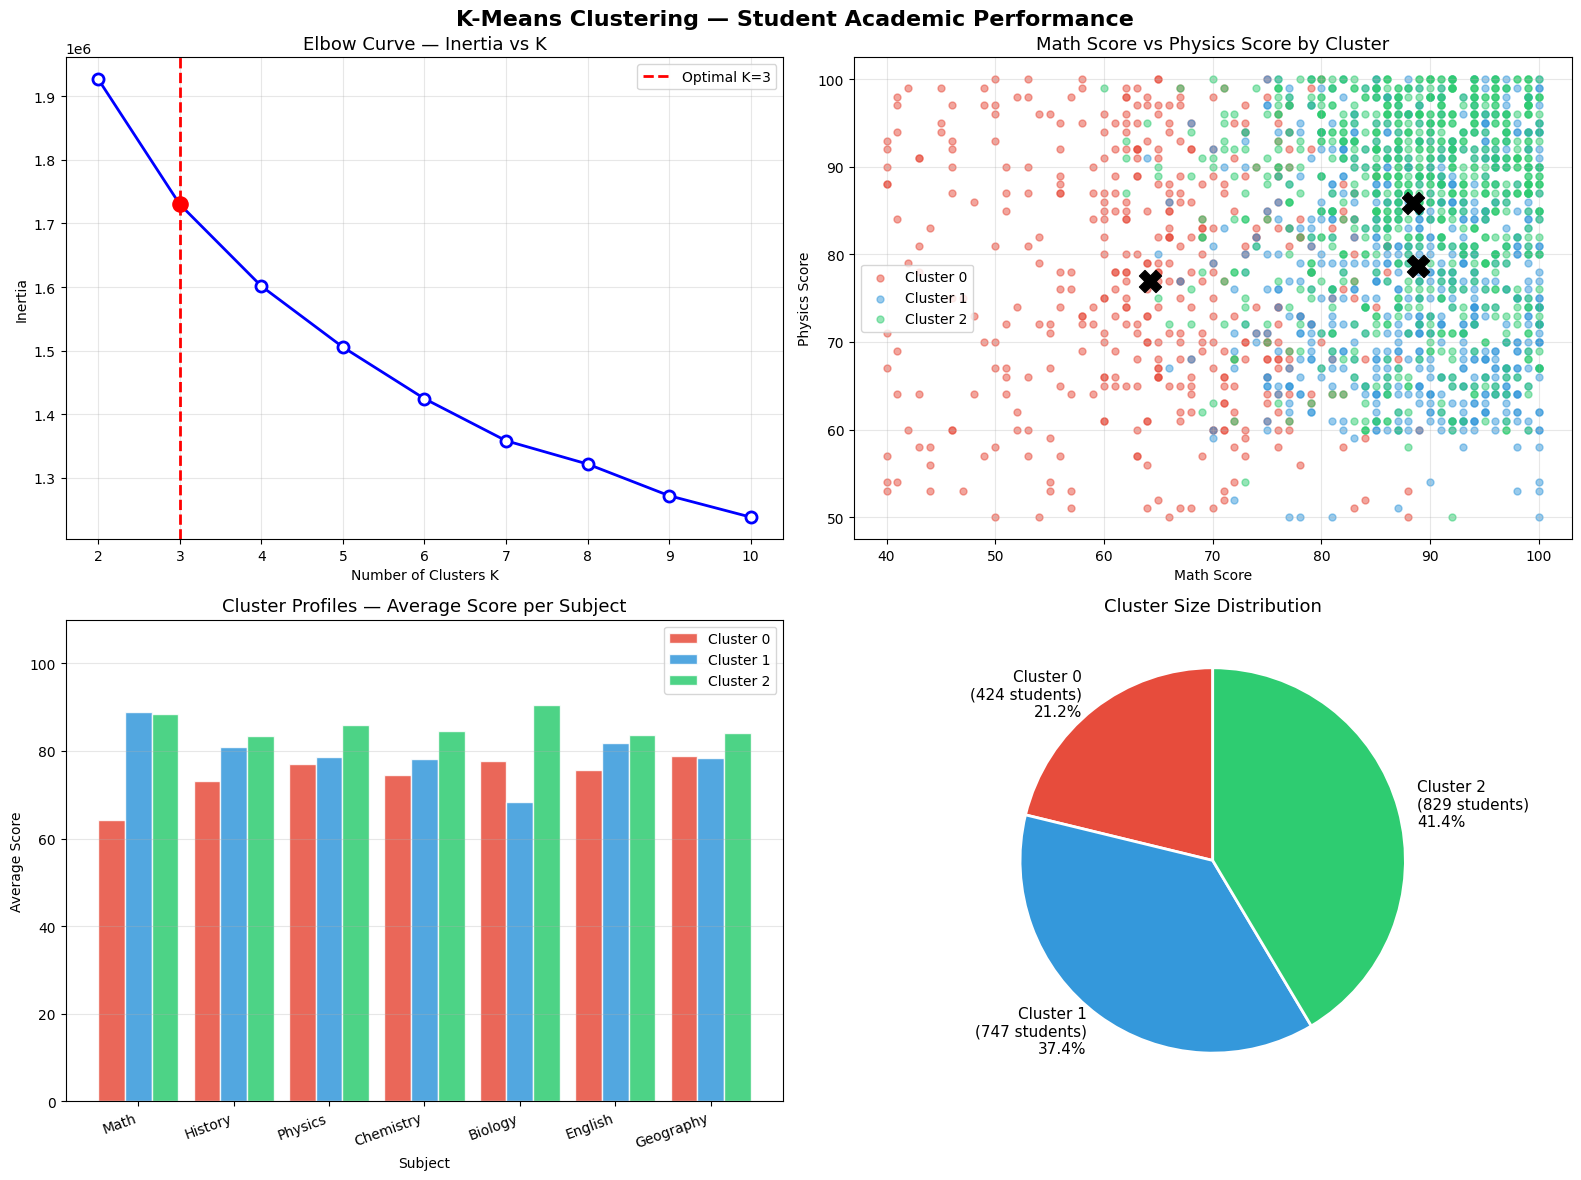

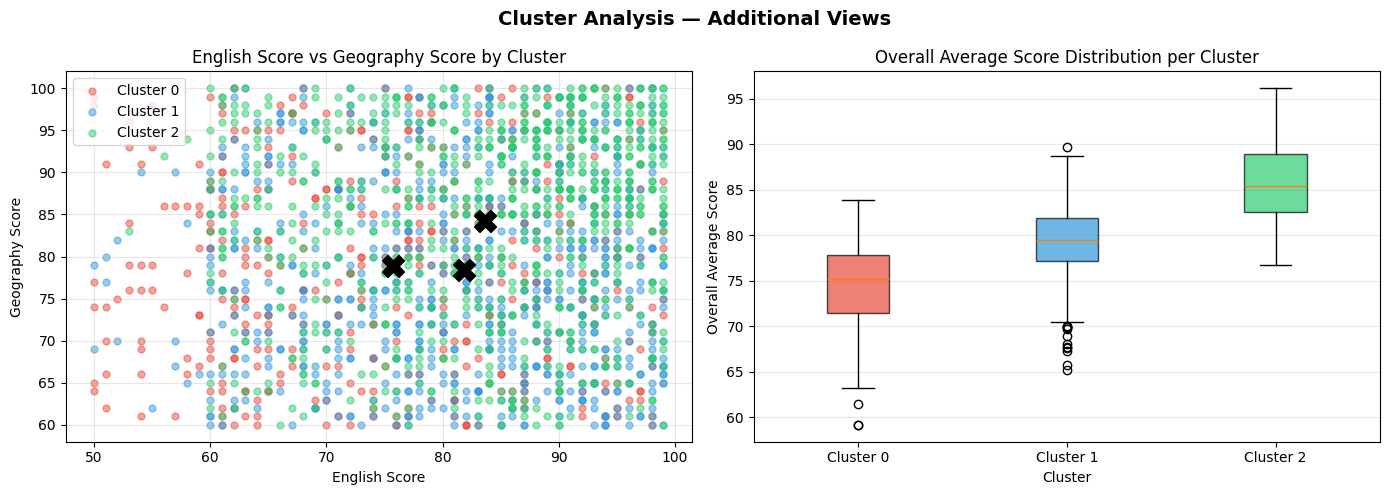

In [35]:
# Visualization

colors = ['#E74C3C', '#3498DB', '#2ECC71']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']
scatter_colors = [colors[c] for c in final_labels]

# FIGURE 1 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-Means Clustering — Student Academic Performance',
             fontsize=16, fontweight='bold')

# Graph 1 — Elbow curve
axes[0, 0].plot(k_values, inertias, 'bo-', linewidth=2,
                markersize=8, markerfacecolor='white',
                markeredgewidth=2)
axes[0, 0].axvline(x=optimal_k, color='red',
                    linestyle='--', linewidth=2,
                    label=f'Optimal K={optimal_k}')
axes[0, 0].scatter([optimal_k],
                    [inertias[k_values.index(optimal_k)]],
                    color='red', s=120, zorder=5)
axes[0, 0].set_title('Elbow Curve — Inertia vs K', fontsize=13)
axes[0, 0].set_xlabel('Number of Clusters K')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(k_values)

# Graph 2 — Scatter: math vs physics
for i in range(optimal_k):
    mask = final_labels == i
    axes[0, 1].scatter(
        df[mask]['math_score'],
        df[mask]['physics_score'],
        c=colors[i], alpha=0.5, s=25,
        label=f'Cluster {i}'
    )
for i, centroid in enumerate(final_model.centroids):
    axes[0, 1].scatter(centroid[0], centroid[2],
                        c='black', marker='X', s=250,
                        zorder=10)
axes[0, 1].set_title('Math Score vs Physics Score by Cluster',
                      fontsize=13)
axes[0, 1].set_xlabel('Math Score')
axes[0, 1].set_ylabel('Physics Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Graph 3 — Bar chart: cluster profiles
cluster_profiles_plot = df.groupby('cluster')[features].mean()
x = np.arange(len(features))
width = 0.28
for i in range(optimal_k):
    axes[1, 0].bar(x + i * width,
                    cluster_profiles_plot.loc[i],
                    width, label=f'Cluster {i}',
                    color=colors[i], alpha=0.85,
                    edgecolor='white')
axes[1, 0].set_title('Cluster Profiles — Average Score per Subject',
                      fontsize=13)
axes[1, 0].set_xlabel('Subject')
axes[1, 0].set_ylabel('Average Score')
axes[1, 0].set_xticks(x + width)
axes[1, 0].set_xticklabels(
    ['Math', 'History', 'Physics', 'Chemistry',
     'Biology', 'English', 'Geography'],
    rotation=20, ha='right'
)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim(0, 110)

# Graph 4 — Pie chart: cluster sizes
cluster_counts = df['cluster'].value_counts().sort_index()
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1, 1].pie(
    cluster_counts,
    labels=[f'Cluster {i}\n({v} students)\n{v/len(df)*100:.1f}%'
            for i, v in cluster_counts.items()],
    colors=colors,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
axes[1, 1].set_title('Cluster Size Distribution', fontsize=13)

plt.tight_layout()
plt.show()

# FIGURE 2 Scatter: english vs geography
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Cluster Analysis — Additional Views',
              fontsize=14, fontweight='bold')

# Scatter: english vs geography
for i in range(optimal_k):
    mask = final_labels == i
    axes2[0].scatter(
        df[mask]['english_score'],
        df[mask]['geography_score'],
        c=colors[i], alpha=0.5, s=25,
        label=f'Cluster {i}'
    )
for i, centroid in enumerate(final_model.centroids):
    axes2[0].scatter(centroid[5], centroid[6],
                     c='black', marker='X', s=250, zorder=10)
axes2[0].set_title('English Score vs Geography Score by Cluster',
                    fontsize=12)
axes2[0].set_xlabel('English Score')
axes2[0].set_ylabel('Geography Score')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Boxplot: overall score distribution per cluster
df['overall_avg'] = df[features].mean(axis=1)
cluster_data = [df[df['cluster'] == i]['overall_avg'].values
                for i in range(optimal_k)]
bp = axes2[1].boxplot(cluster_data,
                       tick_labels=[f'Cluster {i}' for i in range(optimal_k)],
                       patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes2[1].set_title('Overall Average Score Distribution per Cluster',
                    fontsize=12)
axes2[1].set_xlabel('Cluster')
axes2[1].set_ylabel('Overall Average Score')
axes2[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Analysis
1. How many clusters did you choose?

We chose K=3 as the optimal number of clusters.

2. Why did you choose this number?

The elbow curve shows the largest inertia drop between K=2 and K=3 — a reduction of 196,682 points (10.2%). 
After K=3 each additional cluster reduces inertia by less and less: 7.4% at K=4, 6.0% at K=5, down to just 2.6% at K=10. This means K=3 is the point where adding more clusters stops being worth it.

Looking at K=2: students are split almost 50/50 (1012 vs 988) which is too rough — no meaningful performance grouping.
Looking at K=4+: groups become very similar in size (around 25% each) and harder to interpret meaningfully.
K=3 gives the most natural and interpretable split.

3. What patterns do the clusters show?

Cluster 0 — STRUGGLING STUDENTS (424 students, 21.2%):
Overall average score: 74.44 — lowest of all groups.
Weakest subject: math_score (64.26) — significantly below average.
Strongest subject: geography_score (78.82).
These students struggle most with analytical STEM subjects.
The low math score (64.26) stands out — it is 24 points lower
than Cluster 1's math score. These students need targeted support.

Cluster 1 — MIXED PROFILE STUDENTS (747 students, 37.4%):
Overall average score: 79.32 — middle performance level.
Surprisingly strong in math (88.86) but very weak in biology (68.42).
This is an interesting pattern — strong analytical skills
but weaker in life sciences. These students show uneven performance
across STEM vs life science subjects.

Cluster 2 — HIGH PERFORMERS (829 students, 41.4%):
Overall average score: 85.82 — highest of all groups.
Strongest subject: biology_score (90.61).
Even their weakest subject history_score (83.44) is higher
than Cluster 1's average overall. These students perform
consistently well across all 7 subjects.

4. Do clusters correspond to real-world meaning?

Yes, the three clusters map directly to academic performance levels that teachers observe in real classrooms every day.

Cluster 0 = students who need additional support and tutoring
Cluster 1 = students with uneven skills needing targeted guidance
Cluster 2 = advanced students ready for enriched curriculum

One surprising finding: Cluster 2 is the LARGEST group (41.4%),
suggesting this school has a high-performing student population overall.

The correlation matrix confirmed that individual subjects are weakly correlated (0.05-0.15), meaning students are grouped by their OVERALL performance level rather than subject specialization. The scatter plots confirm this — clusters overlap significantly when comparing any two individual subjects, but the boxplot of overall average scores shows clear separation between groups.

## Conclusion

In this practice, I applied K-Means clustering to automatically discover natural performance groups among 2000 students based on their scores across 7 subjects: math, history, physics, chemistry, biology, english and geography.

The K-Means algorithm was built entirely from scratch using KMeans++ initialization for better centroid placement, which ensures centroids start spread far apart and converge faster compared to purely random initialization.

By testing K values from 2 to 10 using the elbow method, K=3 was identified as optimal — it produced the largest single inertia drop of 10.2% while remaining interpretable.

The three clusters correspond to meaningful academic groups:
Cluster 0 (424 struggling students, avg 74.44),
Cluster 1 (747 mixed-profile students, avg 79.32),
and Cluster 2 (829 high performers, avg 85.82).

The weak correlations between subjects (0.05-0.15) confirmed that clustering captures overall performance level rather than subject specialization, making K=3 both mathematically optimal and educationally meaningful.